## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA

import numpy as np
import torch
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from os.path import join
import pandas as pd
np.random.seed(0)


In [2]:
# # 读取encoded数据
# import zipfile
# with zipfile.ZipFile(join(data_path, 'autoencoder_csv.zip'), 'r') as zip_ref:
#     # for name in zip_ref.namelist():
#     #     print(name)
#     with zip_ref.open('autoencoder_csv/GSE140203_mouse_skin_Gene_normalized_downsampling_encoded.csv') as file:
#         data1 = pd.read_csv(file, index_col=0)
#     with zip_ref.open('autoencoder_csv/GSE140203_mouse_skin_PeakonGene_normalized_downsampling_encoded.csv') as file:
#         data2 = pd.read_csv(file, index_col=0)
#     with zip_ref.open('autoencoder_csv/GSE140203_mouse_skin_Gene_plus_PeakonGene_normalized_downsampling_encoded.csv') as file:
#         data3 = pd.read_csv(file, index_col=0)
#     with zip_ref.open('autoencoder_csv/GSE140203_mouse_skin_Gene_times_PeakonGene_normalized_downsampling_encoded.csv') as file:
#         data4 = pd.read_csv(file, index_col=0)
# # 保存为npz文件
# np.savez(join(data_path, 'skin_normalized.npz'), gene=data1.values, peak=data2.values, gene_plus_peak=data3.values, gene_times_peak=data4.values)


In [3]:
# data_path = '/home/lqr/CLIMA/datasets/section2/processed_data'
# data = np.load(join(data_path, 'data.npz'))
# gene = np.squeeze(data['arr_0'], axis=0)
# peak = np.squeeze(data['arr_1'], axis=0)
data_path = '/home/lqr/CLIMA/datasets/new_simu/skin_sample'
data = np.load(join(data_path, 'skin_normalized.npz'))
all_gene = data['gene']
all_peak = data['peak']
# all_gene_peak = data['gene_plus_peak']
gene = all_gene[:2500, :]
peak = all_peak[:2500, :]
# gene_peak = all_gene_peak[:2500, :]
print(f"all_gene.shape: {all_gene.shape}")
print(f"all_peak.shape: {all_peak.shape}")
print(f"gene.shape: {gene.shape}")
print(f"peak.shape: {peak.shape}")

all_gene.shape: (4531, 23296)
all_peak.shape: (4531, 23296)
gene.shape: (2500, 23296)
peak.shape: (2500, 23296)


In [43]:
# gene_peak = gene * peak
gene_peak = gene + peak

## Generate simulation data

In [44]:
print(f"gene_sum: {np.sum(gene)}")
print(f"peak_sum: {np.sum(peak)}")
# 找出所有值都为空的列
gene_empty_cols = np.all(gene == 0, axis=0)
peak_empty_cols = np.all(peak == 0, axis=0)
print(f"gene_empty_cols: {np.sum(gene_empty_cols)}")
print(f"peak_empty_cols: {np.sum(peak_empty_cols)}")

gene_sum: 3854851.299286427
peak_sum: 897352.7296186143
gene_empty_cols: 4241
peak_empty_cols: 21878



Simulation parameters



Use simulation tool to generate multi-modality data

## Analyses based on single modality

Learn features from single modality

In [46]:
latent_dim = 100
view_gene_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(gene)
view_peak_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(peak)
view_ab_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(gene_peak)

In [47]:
print(f"gene.shape: {gene.shape}")
print(f"peak.shape: {peak.shape}")
print(f"view_gene_feature.shape: {view_gene_feature.shape}")
print(f"view_peak_feature.shape: {view_peak_feature.shape}")

gene.shape: (2500, 23296)
peak.shape: (2500, 23296)
view_gene_feature.shape: (2500, 100)
view_peak_feature.shape: (2500, 100)


Perform clustering using PhenoGraph

In [48]:
view_gene_label, _, _ = phenograph.cluster(view_gene_feature, random_state=42)
view_peak_label, _, _ = phenograph.cluster(view_peak_feature, random_state=42)
view_ab_label, _, _ = phenograph.cluster(view_ab_feature, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.014155149459838867 seconds
Jaccard graph constructed in 0.6688861846923828 seconds
Wrote graph to binary file in 0.01263284683227539 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.72799
After 5 runs, maximum modularity is Q = 0.72906
After 7 runs, maximum modularity is Q = 0.730782
Louvain completed 27 runs in 2.052218198776245 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 3.3620598316192627 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07756924629211426 seconds
Jaccard graph constructed in 0.7031574249267578 seconds
Wrote graph to binary file in 0.01205754280090332 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.572628
After 3 runs, maximum modularity is Q = 0.577389
After 4 runs, maximum modularity is Q = 0.579627
Lo

In [49]:
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_gene_feature)
Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_peak_feature)
XY_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_ab_feature)

X_embedded: (2500, 2)
label_true: (2500,)


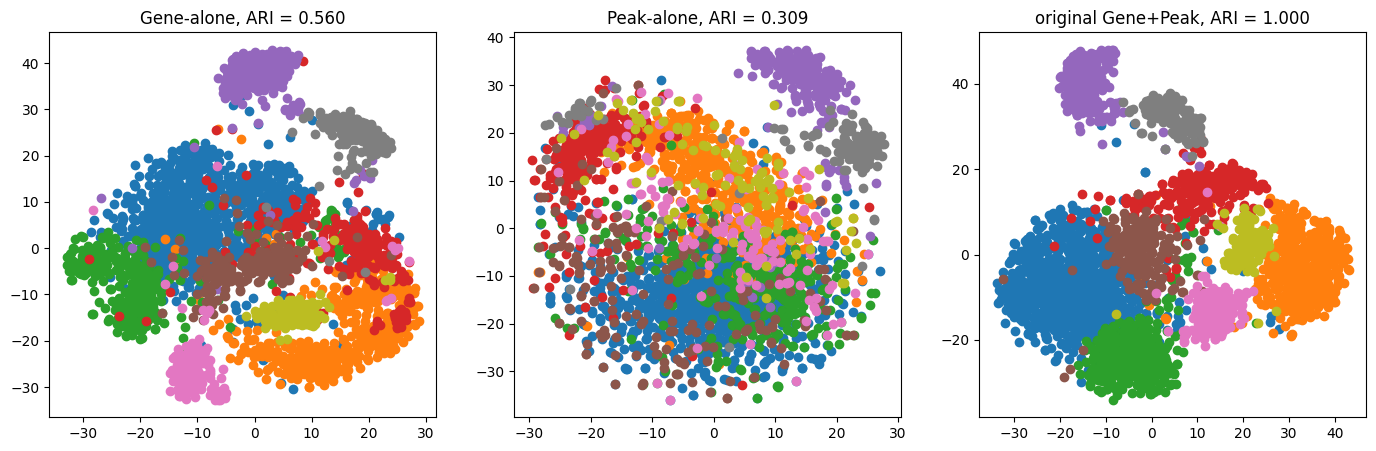

In [51]:
plt.figure(figsize=(17, 5))
# Gene-alone
plt.subplot(1, 3, 1)
print(f"X_embedded: {X_embedded.shape}")
print(f"label_true: {view_ab_label.shape}")
# 遍历每一个类别
for i in np.unique(view_ab_label):
    # 找到所有类别为i的索引
    idx = np.nonzero(view_ab_label == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('Gene-alone, ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_gene_label))

# Peak-alone
plt.subplot(1, 3, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('Peak-alone, ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_peak_label))

# original Gene+Peak
plt.subplot(1, 3, 3)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(XY_embedded[idx, 0], XY_embedded[idx, 1])
    plt.title('original Gene+Peak, ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_ab_label))

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [11]:
gene.shape

(2500, 23296)

In [52]:
outputs = muse.dual_muse_fit_predict(
    [gene, peak],
    [gene_peak],
    [view_gene_label, view_peak_label],
    [view_ab_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=10,
    weight_penalty=1,
    triplet_lambda=10,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++


#epoch: 0/200 	 total loss: 489.93 	 sc loss: 260.35 	 st loss: 178.44 	 infoNCE: 51.14 	 sc recon: 106.18 	 st recon: 79.03 	 sc sparse: 139.55 	 st sparse: 99.41 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 14.62 	 st infoNCE: 0.00
#epoch: 25/200 	 total loss: 378.20 	 sc loss: 217.82 	 st loss: 155.91 	 infoNCE: 4.47 	 sc recon: 87.02 	 st recon: 63.95 	 sc sparse: 129.09 	 st sparse: 91.96 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 1.71 	 st infoNCE: 0.00
#epoch: 50/200 	 total loss: 355.75 	 sc loss: 205.80 	 st loss: 147.70 	 infoNCE: 2.25 	 sc recon: 85.96 	 st recon: 62.92 	 sc sparse: 118.95 	 st sparse: 84.78 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.89 	 st infoNCE: 0.00
#epoch: 75/200 	 total loss: 337.06 	 sc loss: 195.18 	 st loss: 140.14 	 infoNCE: 1.73 	 sc recon: 85.26 	 st recon: 62.22 	 sc sparse: 109.27 	 st sparse: 77.92 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.65 	 st infoNCE: 0.00
#epoch: 100/200 	 total loss: 319.85 	 sc loss: 185.06 	 st loss: 

In [53]:
latent_sc = (outputs[0])
latent_st = (outputs[1])
reconstruct_sc = (outputs[2])
reconstruct_st = (outputs[3])
encoded_sc = (outputs[4])
encoded_st = (outputs[5])
print(f"latent_sc: {latent_sc.shape}")
print(f"latent_st: {latent_st.shape}")
print(f"reconstruct_sc: {len(reconstruct_sc)}")
print(f"reconstruct_st: {len(reconstruct_st)}")
print(f"encoded_sc: {encoded_sc.shape}")
print(f"encoded_st: {encoded_st.shape}")

latent_sc: (2500, 100)
latent_st: (2500, 100)
reconstruct_sc: 2
reconstruct_st: 1
encoded_sc: (2, 2500, 128)
encoded_st: (1, 2500, 128)


## Perform clustering
PhenoGraph clustering

In [14]:
latent_label_sc, _, _ = phenograph.cluster(latent_sc, random_state=42)
latent_label_st, _, _ = phenograph.cluster(latent_st, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.08106732368469238 seconds
Jaccard graph constructed in 0.6618838310241699 seconds
Wrote graph to binary file in 0.008819341659545898 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.897217
Louvain completed 21 runs in 1.31520414352417 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.641592264175415 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07590031623840332 seconds
Jaccard graph constructed in 0.6528198719024658 seconds
Wrote graph to binary file in 0.009027957916259766 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.812403
Louvain completed 21 runs in 1.3540503978729248 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.6783597469329834 seconds


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

In [15]:
# latent_X_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_sc)
# latent_Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_st)

KeyboardInterrupt: 

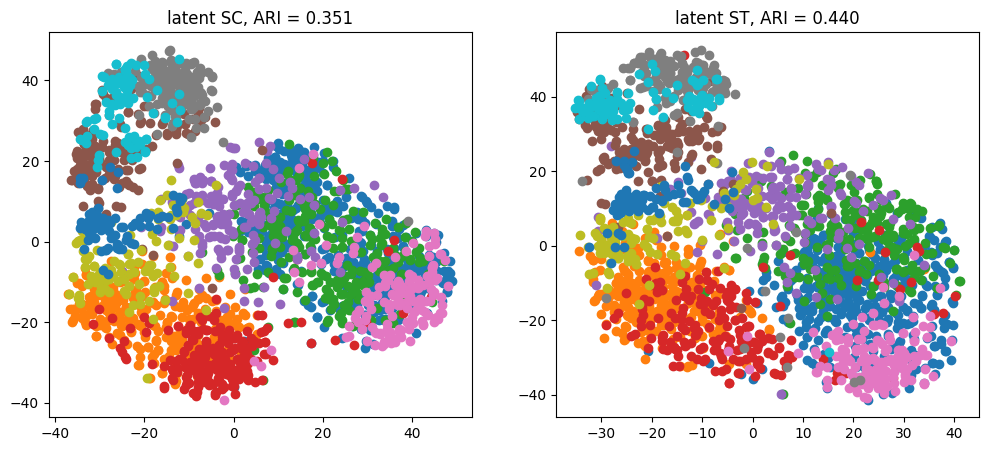

In [25]:
# plt.figure(figsize=(12, 5))
# # Gene, Peak MUSE(latent sc)
# plt.subplot(1, 2, 1)
# for i in np.unique(view_ab_label):
#     idx = np.nonzero(view_ab_label == i)[0]
#     plt.scatter(latent_X_embedded[idx, 0], latent_X_embedded[idx, 1])
#     plt.title('latent SC, ARI = %01.3f' % adjusted_rand_score(view_ab_label, latent_label_sc))

# # Peak+Gene MUSE(latent st)
# plt.subplot(1, 2, 2)
# for i in np.unique(view_ab_label):
#     idx = np.nonzero(view_ab_label == i)[0]
#     plt.scatter(latent_Y_embedded[idx, 0], latent_Y_embedded[idx, 1])
#     plt.title('latent ST, ARI = %01.3f' % adjusted_rand_score(view_ab_label, latent_label_st))

# plt.show()

In [16]:
print('ARI: ', adjusted_rand_score(latent_label_sc, latent_label_st))

ARI:  0.1924595676958402


In [93]:
# # # PCA降维
# # # latent_sc = PCA(n_components=100, random_state=42).fit_transform(all_gene[2500:, :])
# # # latent_st = PCA(n_components=100, random_state=42).fit_transform(all_peak[2500:, :])
# # # 训练的输出
# # # latent_sc = outputs[0]
# # # latent_st = outputs[1]
# # # 未训练
# latent_sc = all_gene[3000:]
# latent_st = all_peak[3000:]
# # # 预测的输出
latent_sc = out[0][0].cpu().numpy()
latent_st = out[0][1].cpu().numpy()

**************************************************
S: torch.Size([1531, 100, 1])
G: torch.Size([1531, 100, 1])


  6%|▌         | 31/500 [00:00<00:01, 304.90it/s]

Epoch 50: Loss -0.910231351852417


 19%|█▉        | 97/500 [00:00<00:01, 319.33it/s]

Epoch 100: Loss -1.0042388439178467


...

Epoch 400: Loss -1.1414273977279663


 92%|█████████▏| 459/500 [00:01<00:00, 320.16it/s]

Epoch 450: Loss -1.1321824789047241


100%|██████████| 500/500 [00:01<00:00, 320.01it/s]

Epoch 500: Loss -1.148351788520813
[[ 5.826361    1.5948365  -1.8176391  ...  2.207772    3.291437
   0.2591196 ]
 [ 0.6507717   6.1176996  -3.2437491  ... -2.487986   -1.5026498
   1.5453026 ]
 [-1.005036   -2.1018095   6.2009735  ...  0.6291051   0.07068439
   0.62858224]
 ...
 [-3.600982   -0.9102863  -0.46103257 ...  5.9091063   1.7082422
   4.966982  ]
 [ 5.3559055  -3.414885   -3.8780737  ...  2.1761668   6.4450426
  -2.0429277 ]
 [-0.9274542   2.406218   -1.7216685  ... -1.6483349  -0.105966
   6.2931666 ]]


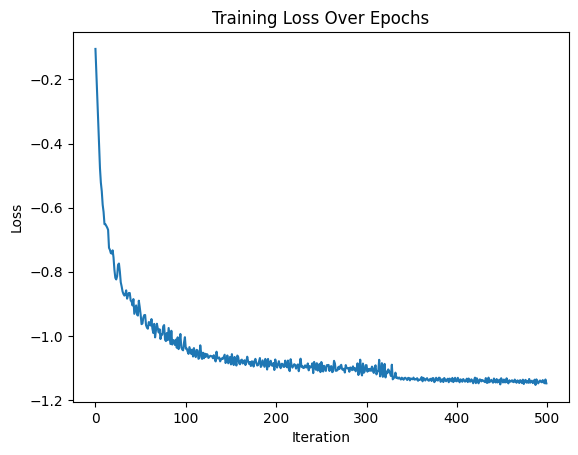

In [94]:
from sim_tangram.train_tangram import read_csv_and_run_tangram
import torch

# tangram
tangram_sim, _ = read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=50,
    lambda_g1=1,
    lambda_g2=1
)

**************************************************
S: torch.Size([1531, 100, 1])
G: torch.Size([1531, 100, 1])


 72%|███████▏  | 362/500 [00:00<00:00, 1795.63it/s]

100%|██████████| 500/500 [00:00<00:00, 1801.99it/s]


Epoch 500: Loss -1.5812656879425049
[[11.834698    4.018489   -1.8926787  ...  4.310917    9.3783045
  -0.59424484]
 [ 1.682117   11.82279    -2.5657542  ... -3.0459855   0.3299509
   3.6200354 ]
 [-0.81821996 -0.3947177  11.506199   ...  2.1190238  -1.135388
  -0.27822682]
 ...
 [ 0.40997258 -0.2213172  -0.2545207  ... 11.074703    0.8207333
  -0.24712504]
 [ 1.1468532  -2.57088    -2.083744   ... -1.9401617  12.11257
  -2.543431  ]
 [-0.5313602   3.8157287  -2.38229    ... -1.1746614  -0.9944687
  12.0560255 ]]


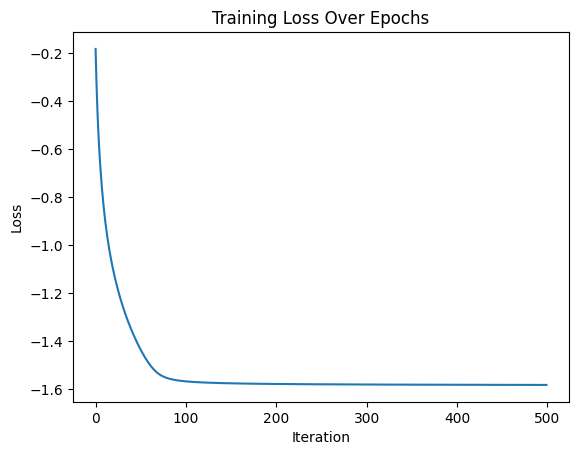

In [95]:
# 用cosine_similarity驱动的tangram进行计算

import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [98]:
# tangram cosine_similarity
cos_tg_mapping = cos_sim_tg.argmax(axis=1)

# # org tangram cca
# org_cca_mapping = cca_sim.argmax(axis=1)
# tangram cca
mapping = tangram_sim.argmax(axis=1)
for i in range(len(mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {mapping[i]:4d}", end="\t")
print('*'*50)
# cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_sc, latent_st)
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")



 0:  853	 1:    1	 2:    2	 3:  110	 4: 1066	
 5: 1493	 6: 1199	 7:    7	 8:    8	 9:    9	
10:  137	11: 1494	12:  187	13:   13	14:  709	
15:   15	16:   16	17: 1366	18:  784	19:  650	
20:   20	21:   21	22: 1277	23: 1500	24:  390	
25:   25	26:   26	27: 1311	28:   28	29:   29	**************************************************

 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	

In [99]:
sample_size = tangram_sim.shape[0]
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
print("cosine accuracy:", cos_acc)
tangram_acc = np.sum(mapping == gt) / sample_size
print("tangram cca accuracy:", tangram_acc)
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size
print("tangram cosine accuracy:", cos_tg_acc)


cosine accuracy: 0.9934683213585892
tangram cca accuracy: 0.44546048334421945
tangram cosine accuracy: 0.9875898105813194


In [90]:
model = outputs[6]

In [92]:
from multi_muse_sc import *

with torch.no_grad():
    data_inputs_tensor_sc = get_all_tensor(
        [all_gene[3000:], all_peak[3000:]]
    )
    data_inputs_tensor_st = get_all_tensor(
        [all_gene[3000:] + all_peak[3000:]]
    )
    out = model(
        data_inputs_tensor_sc,
        data_inputs_tensor_st,
        # info_nce_lambda=1,
    )